<div style="background:linear-gradient(135deg,#42275a 0%,#734b6d 100%);padding:32px 34px;border-radius:16px;
            box-shadow:0 8px 24px rgba(0,0,0,0.18);font-family:'Segoe UI',Roboto,sans-serif;">
  <h1 style="margin:0;color:#ffffff;font-size:34px;letter-spacing:-0.5px;">🧵&nbsp; Scaling Up: Distributed Training</h1>
  <p style="margin:12px 0 0;color:#eaf6ff;font-size:17px;line-height:1.5;max-width:760px;">Production PINNs need millions of collocation points and long schedules. The <code>DistributedTrainer</code> wraps a solver so the same code runs on one CPU here — and scales to many GPUs unchanged.</p>
</div>

<div><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">level</span><span style="background:#d6336c;color:#fff;padding:4px 8px;">advanced</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">topic</span><span style="background:#1a73e8;color:#fff;padding:4px 8px;">data parallelism</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">runtime</span><span style="background:#7b3fe4;color:#fff;padding:4px 8px;">~1 min · CPU</span></span></div>

The key idea behind **data-parallel** training: replicate the model across devices, split each batch
of collocation points among them, then average the gradients. The math is identical to single-device
training — you just get there faster. The `DistributedTrainer` hides the bookkeeping.

<div style="background:#f6f8fa;border:1px solid #e1e4e8;border-radius:10px;padding:18px 24px;
            font-family:'Segoe UI',sans-serif;">
  <b style="font-size:15px;">📑 Table of Contents</b>
  <ol style="margin:10px 0 0;padding-left:20px;font-size:14px;line-height:1.6;">
  <li style="margin:3px 0;"><a href="#idea" style="color:#1a73e8;text-decoration:none;">1 · Data Parallelism in One Picture</a></li>
  <li style="margin:3px 0;"><a href="#setup" style="color:#1a73e8;text-decoration:none;">2 · Setup</a></li>
  <li style="margin:3px 0;"><a href="#train" style="color:#1a73e8;text-decoration:none;">3 · Training Through the Wrapper</a></li>
  <li style="margin:3px 0;"><a href="#result" style="color:#1a73e8;text-decoration:none;">4 · The Result</a></li>
  <li style="margin:3px 0;"><a href="#scaling" style="color:#1a73e8;text-decoration:none;">5 · Scaling to GPUs</a></li>
  <li style="margin:3px 0;"><a href="#takeaways" style="color:#1a73e8;text-decoration:none;">6 · Takeaways</a></li>
  </ol>
</div>

<a id="idea"></a>

## 1 · Data Parallelism in One Picture

```
            batch of collocation points
          ┌───────────┬───────────┬───────────┐
          │  shard 0  │  shard 1  │  shard 2   │
          ▼           ▼           ▼
       model copy  model copy  model copy        (identical weights)
          │           │           │
          └────────► average gradients ◄─────────┘
                          │
                   single optimiser step
```
Every device computes gradients on its shard; the trainer averages them so all replicas stay in sync.

<a id="setup"></a>

## 2 · Setup

In [1]:
# --- Environment setup -------------------------------------------------------
import warnings, logging, os
warnings.filterwarnings("ignore")
logging.getLogger("pinnlab").setLevel(logging.ERROR)          # quiet library logs

# Disable tqdm progress bars for clean, static notebook output
from functools import partialmethod
import tqdm
tqdm.tqdm.__init__ = partialmethod(tqdm.tqdm.__init__, disable=True)

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl

# A clean, consistent "Kaggle" plotting theme ---------------------------------
plt.rcParams.update({
    "figure.figsize":   (9, 5),
    "figure.dpi":       110,
    "savefig.dpi":      110,
    "font.size":        11,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   11,
    "axes.edgecolor":   "#cccccc",
    "axes.grid":        True,
    "grid.color":       "#e6e6e6",
    "grid.linewidth":   0.8,
    "axes.axisbelow":   True,
    "legend.frameon":   True,
    "legend.framealpha":0.9,
})
ACCENT, ACCENT2, ACCENT3 = "#1a73e8", "#d6336c", "#1e9e54"

# Reproducibility -------------------------------------------------------------
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

import pinnlab
print(f"pinnlab      : {pinnlab.__version__}")
print(f"PyTorch      : {torch.__version__}")
print(f"Compute      : {DEVICE.upper()}")

pinnlab      : 0.5.0
PyTorch      : 2.11.0+cpu
Compute      : CPU


<a id="train"></a>

## 3 · Training Through the Wrapper

We build a normal `ContinuousPINN`, hand it to the `DistributedTrainer`, and call `.fit`. On this machine `devices="auto"` resolves to the available CPU.

In [2]:
from pinnlab.models import MLP
from pinnlab.solvers.raissi_improved import (
    BurgersConfig, TrainConfig, ContinuousPINN, burgers_residual)
from pinnlab.distributed import DistributedTrainer

cfg = BurgersConfig()
pinn = ContinuousPINN(MLP(2, 4, 32, 1), DEVICE, burgers_residual, cfg)

trainer = DistributedTrainer(pinn, strategy="data_parallel", devices="auto")
print("Distributed trainer ready:", type(trainer).__name__)

import time; t0 = time.time()
result = trainer.fit(TrainConfig(n_u0=120, n_bc=80, n_f=1_200, adam_steps=1_200,
                                 lbfgs_max_iter=0, seed=SEED, track_losses=True),
                     weights=(10.0, 1.0, 1.0))
print(f"Finished in {time.time()-t0:.0f} s")

Distributed trainer ready: DistributedTrainer


Finished in 15 s


<a id="result"></a>

## 4 · The Result

The wrapper trains the underlying model in place, so we predict exactly as before.

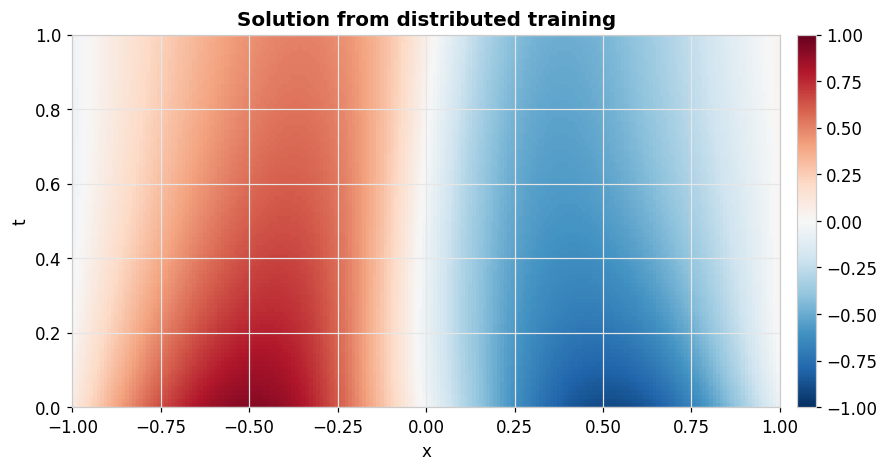

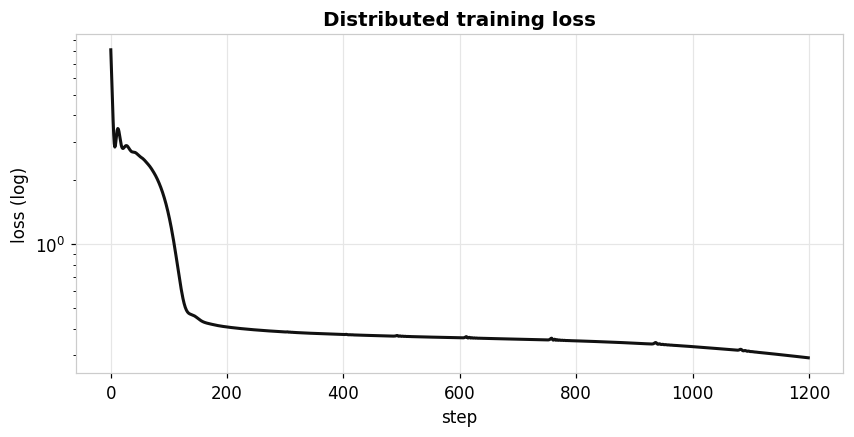

In [3]:
nt, nx = 90, 200
t_grid = np.linspace(cfg.tmin, cfg.tmax, nt, dtype=np.float32)
x_grid = np.linspace(cfg.xmin, cfg.xmax, nx, dtype=np.float32)
TT, XX = np.meshgrid(t_grid, x_grid, indexing="ij")
U = pinn.predict(TT, XX)

fig, ax = plt.subplots(figsize=(10, 4.4))
im = ax.imshow(U, extent=[cfg.xmin, cfg.xmax, cfg.tmin, cfg.tmax], origin="lower",
               aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
ax.set(title="Solution from distributed training", xlabel="x", ylabel="t")
fig.colorbar(im, ax=ax, pad=0.02); plt.show()

# If fit returned a loss history, show it
if isinstance(result, dict) and "total" in result:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(result["total"], color="#111", lw=2); ax.set_yscale("log")
    ax.set(title="Distributed training loss", xlabel="step", ylabel="loss (log)"); plt.show()

<a id="scaling"></a>

## 5 · Scaling to GPUs

The exact same script scales out by changing one argument:

```python
# Multi-GPU on a single node
trainer = DistributedTrainer(pinn, strategy="data_parallel", devices="0,1,2,3")
```

The library also exposes building blocks for advanced setups —
`DistributedPINNTrainer`, `HierarchicalAverager`, `GradientCompression`, and
`DynamicLoadBalancer` — for multi-node clusters and bandwidth-limited links.

<div style="background:#eaf2ff;border-left:5px solid #1a73e8;border-radius:8px;
            padding:14px 18px;margin:6px 0;font-family:'Segoe UI',sans-serif;font-size:14px;line-height:1.6;">
  <b>💡 Note.</b> On CPU you won't see a speed-up — there's only one device — but the <i>code path</i> is identical to a multi-GPU run, so what you debug here is what you deploy at scale.
</div>

<a id="takeaways"></a>

## 6 · Takeaways

- `DistributedTrainer` makes scaling a **configuration change**, not a rewrite.
- Data parallelism keeps the optimisation mathematically identical while spreading the collocation
  workload across devices.
- For large-scale runs, combine it with adaptive sampling
  ([`benchmarks/01`](../benchmarks/01_active_learning_comparison.ipynb)) and progressive training
  ([`04`](04_multi_scale_training.ipynb)).

### 📚 References

1. Goyal, P. et al. (2017). *Accurate, large minibatch SGD*. arXiv:1706.02677.
2. Shukla, K. et al. (2021). *Parallel PINNs via domain decomposition*. J. Comput. Phys., 447.

<div style="background:#0d1117;border-radius:12px;padding:22px 26px;color:#c9d1d9;
            font-family:'Segoe UI',sans-serif;font-size:13px;line-height:1.6;">
  <b style="color:#fff;font-size:15px;">Thanks for reading! 🙌</b><br>
  This notebook is part of the <code>pinnlab</code> example gallery. Explore the companion notebooks in
  <code>notebooks/basic</code>, <code>notebooks/advanced</code>, and <code>notebooks/benchmarks</code>
  for more physics-informed deep-learning recipes.
</div>